# 📈 Regresión Lineal desde cero

## ¿Qué es la regresión lineal?

La **regresión lineal** es el algoritmo de *machine learning* supervisado más simple y uno de los más utilizados para entender los fundamentos.

Dado un conjunto de puntos, intenta encontrar **la línea recta que mejor los describe**.

Su ecuación es:

$$
\hat{y} = w \cdot x + b
$$

Donde:

- $x$ → variable de entrada (feature, variable independiente)  
- $\hat{y}$ → predicción (valor estimado)  
- $w$ → **peso** o pendiente (*slope*) — cuánto cambia $\hat{y}$ por cada unidad que aumenta $x$  
- $b$ → **bias** o intercepto (ordenada en el origen) — valor de $\hat{y}$ cuando $x = 0$

## ¿Cómo aprende el modelo?

El modelo aprende ajustando los valores de $w$ y $b$ para **minimizar el error** entre las predicciones y los valores reales.

La función de error más común es el **MSE** (Mean Squared Error):

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Para minimizar este error usamos **Gradient Descent** (descenso de gradiente).  
Actualizamos los parámetros en cada iteración dando pequeños pasos en la dirección que reduce el error:

$$
w \leftarrow w - \alpha \cdot \frac{\partial \text{MSE}}{\partial w}
$$

$$
b \leftarrow b - \alpha \cdot \frac{\partial \text{MSE}}{\partial b}
$$

Donde:

- $\alpha$ → **learning rate** (tasa de aprendizaje) — controla el tamaño de los pasos  
  (muy pequeño → aprende muy lento / muy grande → puede no converger)

## Dataset de ejemplo

Usaremos un caso muy intuitivo y fácil de visualizar:

> **Horas de estudio → Nota del examen**

Lógica esperada:  
**más horas de estudio → mejor nota** (relación aproximadamente lineal)

Ejemplo de datos típicos:

| Horas de estudio | Nota (0–100) |
|------------------|--------------|
| 1.5              | 55           |
| 2.8              | 68           |
| 4.0              | 78           |
| 5.2              | 85           |
| 7.1              | 92           |



In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# 1️⃣ Parte 1 — Implementación simple (funciones sueltas)

Empezamos con lo más básico: funciones independientes.
Así entendemos cada pieza antes de encapsularla.

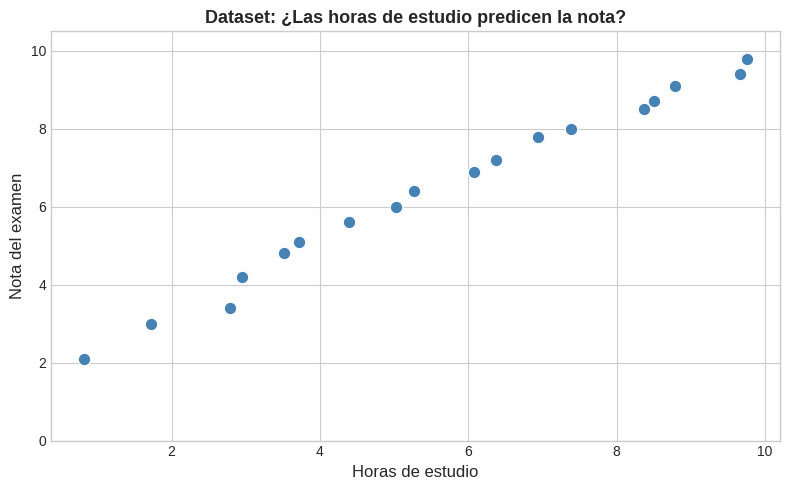

Nº de muestras: 18
Horas → min: 0.8183951848957578, max: 9.755831270005796
Notas → min: 2.10, max: 9.80


In [42]:

hours = np.array([1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10], dtype=float)
grades = np.array([2.1, 3.0, 3.4, 4.2, 4.8, 5.1, 5.6, 6.0, 6.4, 6.9, 7.2, 7.8, 8.0, 8.5, 8.7, 9.1, 9.4, 9.8], dtype=float)

# Añadimos ruido para que sea más realista
hours += np.random.normal(0, 0.2, size=len(grades))
grades  = np.clip(grades, 0, 10)  # Notas entre 0 y 10

# Visualización inicial
plt.figure(figsize=(8, 5))
plt.scatter(hours, grades, color='steelblue', s=80, edgecolors='white', linewidths=0.8, zorder=3)
plt.xlabel('Horas de estudio', fontsize=12)
plt.ylabel('Nota del examen', fontsize=12)
plt.title('Dataset: ¿Las horas de estudio predicen la nota?', fontsize=13, fontweight='bold')
plt.ylim(0, 10.5)
plt.tight_layout()
plt.show()

print(f"Nº de muestras: {len(hours)}")
print(f"Horas → min: {hours.min()}, max: {hours.max()}")
print(f"Notas → min: {grades.min():.2f}, max: {grades.max():.2f}")


# Paso 1 — Inicializar parámetros

Empezamos con $w = 0$ y $b = 0$. El modelo no sabe nada aún.

In [43]:
def predict(x, w, b):
    """ŷ = w·x + b"""
    return w * x + b

def calculate_mse(y_real, y_pred):
    """MSE = mean((y - ŷ)²)"""
    return np.mean((y_real - y_pred) ** 2)

def calculate_gradients(x, y_real, y_pred):
    """
    Derivadas parciales del MSE respecto a w y b.
    dMSE/dw = -2/n · Σ x·(y - ŷ)
    dMSE/db = -2/n · Σ (y - ŷ)
    """
    n = len(y_real)
    error = y_real - y_pred
    dw = (-2 / n) * np.sum(x * error)
    db = (-2 / n) * np.sum(error)
    return dw, db


w, b = 0.0, 0.0
y_pred_inicial = predict(hours, w, b)
print(f"Initial state → w={w}, b={b}")
print(f"MSE inicial:    {calculate_mse(grades, y_pred_inicial):.4f}")

Estado inicial → w=0.0, b=0.0
MSE inicial:    46.6344


# Paso 2 — Entrenamiento con Gradient Descent

En cada **epoch** (iteración completa sobre los datos):
1. Calculamos las predicciones con los pesos actuales
2. Calculamos el error (MSE)
3. Calculamos los gradientes
4. Actualizamos $w$ y $b$

Repetimos hasta que el error converja.

In [45]:

# Hiperparámetros
learning_rate = 0.01
epochs = 1

# Historial para visualizar
historial_loss = []

w, b = 0.0, 0.0  # Reset

for epoch in range(epochs):
    y_pred = predict(hours, w, b)
    loss  = calculate_mse(grades, y_pred)
    dw, db = calculate_gradients(hours, grades, y_pred)

    # Actualización de parámetros
    w -= learning_rate * dw
    b -= learning_rate * db

    historial_loss.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | MSE: {loss:.4f} | w: {w:.4f} | b: {b:.4f}")

print(f"\n✅ Training finish")
print(f" learned parameters → w = {w:.4f}, b = {b:.4f}")
print(f" Final MSE: {historial_loss[-1]:.4f}")

Epoch    0 | MSE: 46.6344 | w: 0.8506 | b: 0.1289

✅ Training finish
 learned parameters → w = 0.8506, b = 0.1289
 Final MSE: 46.6344


/tmp/ipykernel_1106/3022323296.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


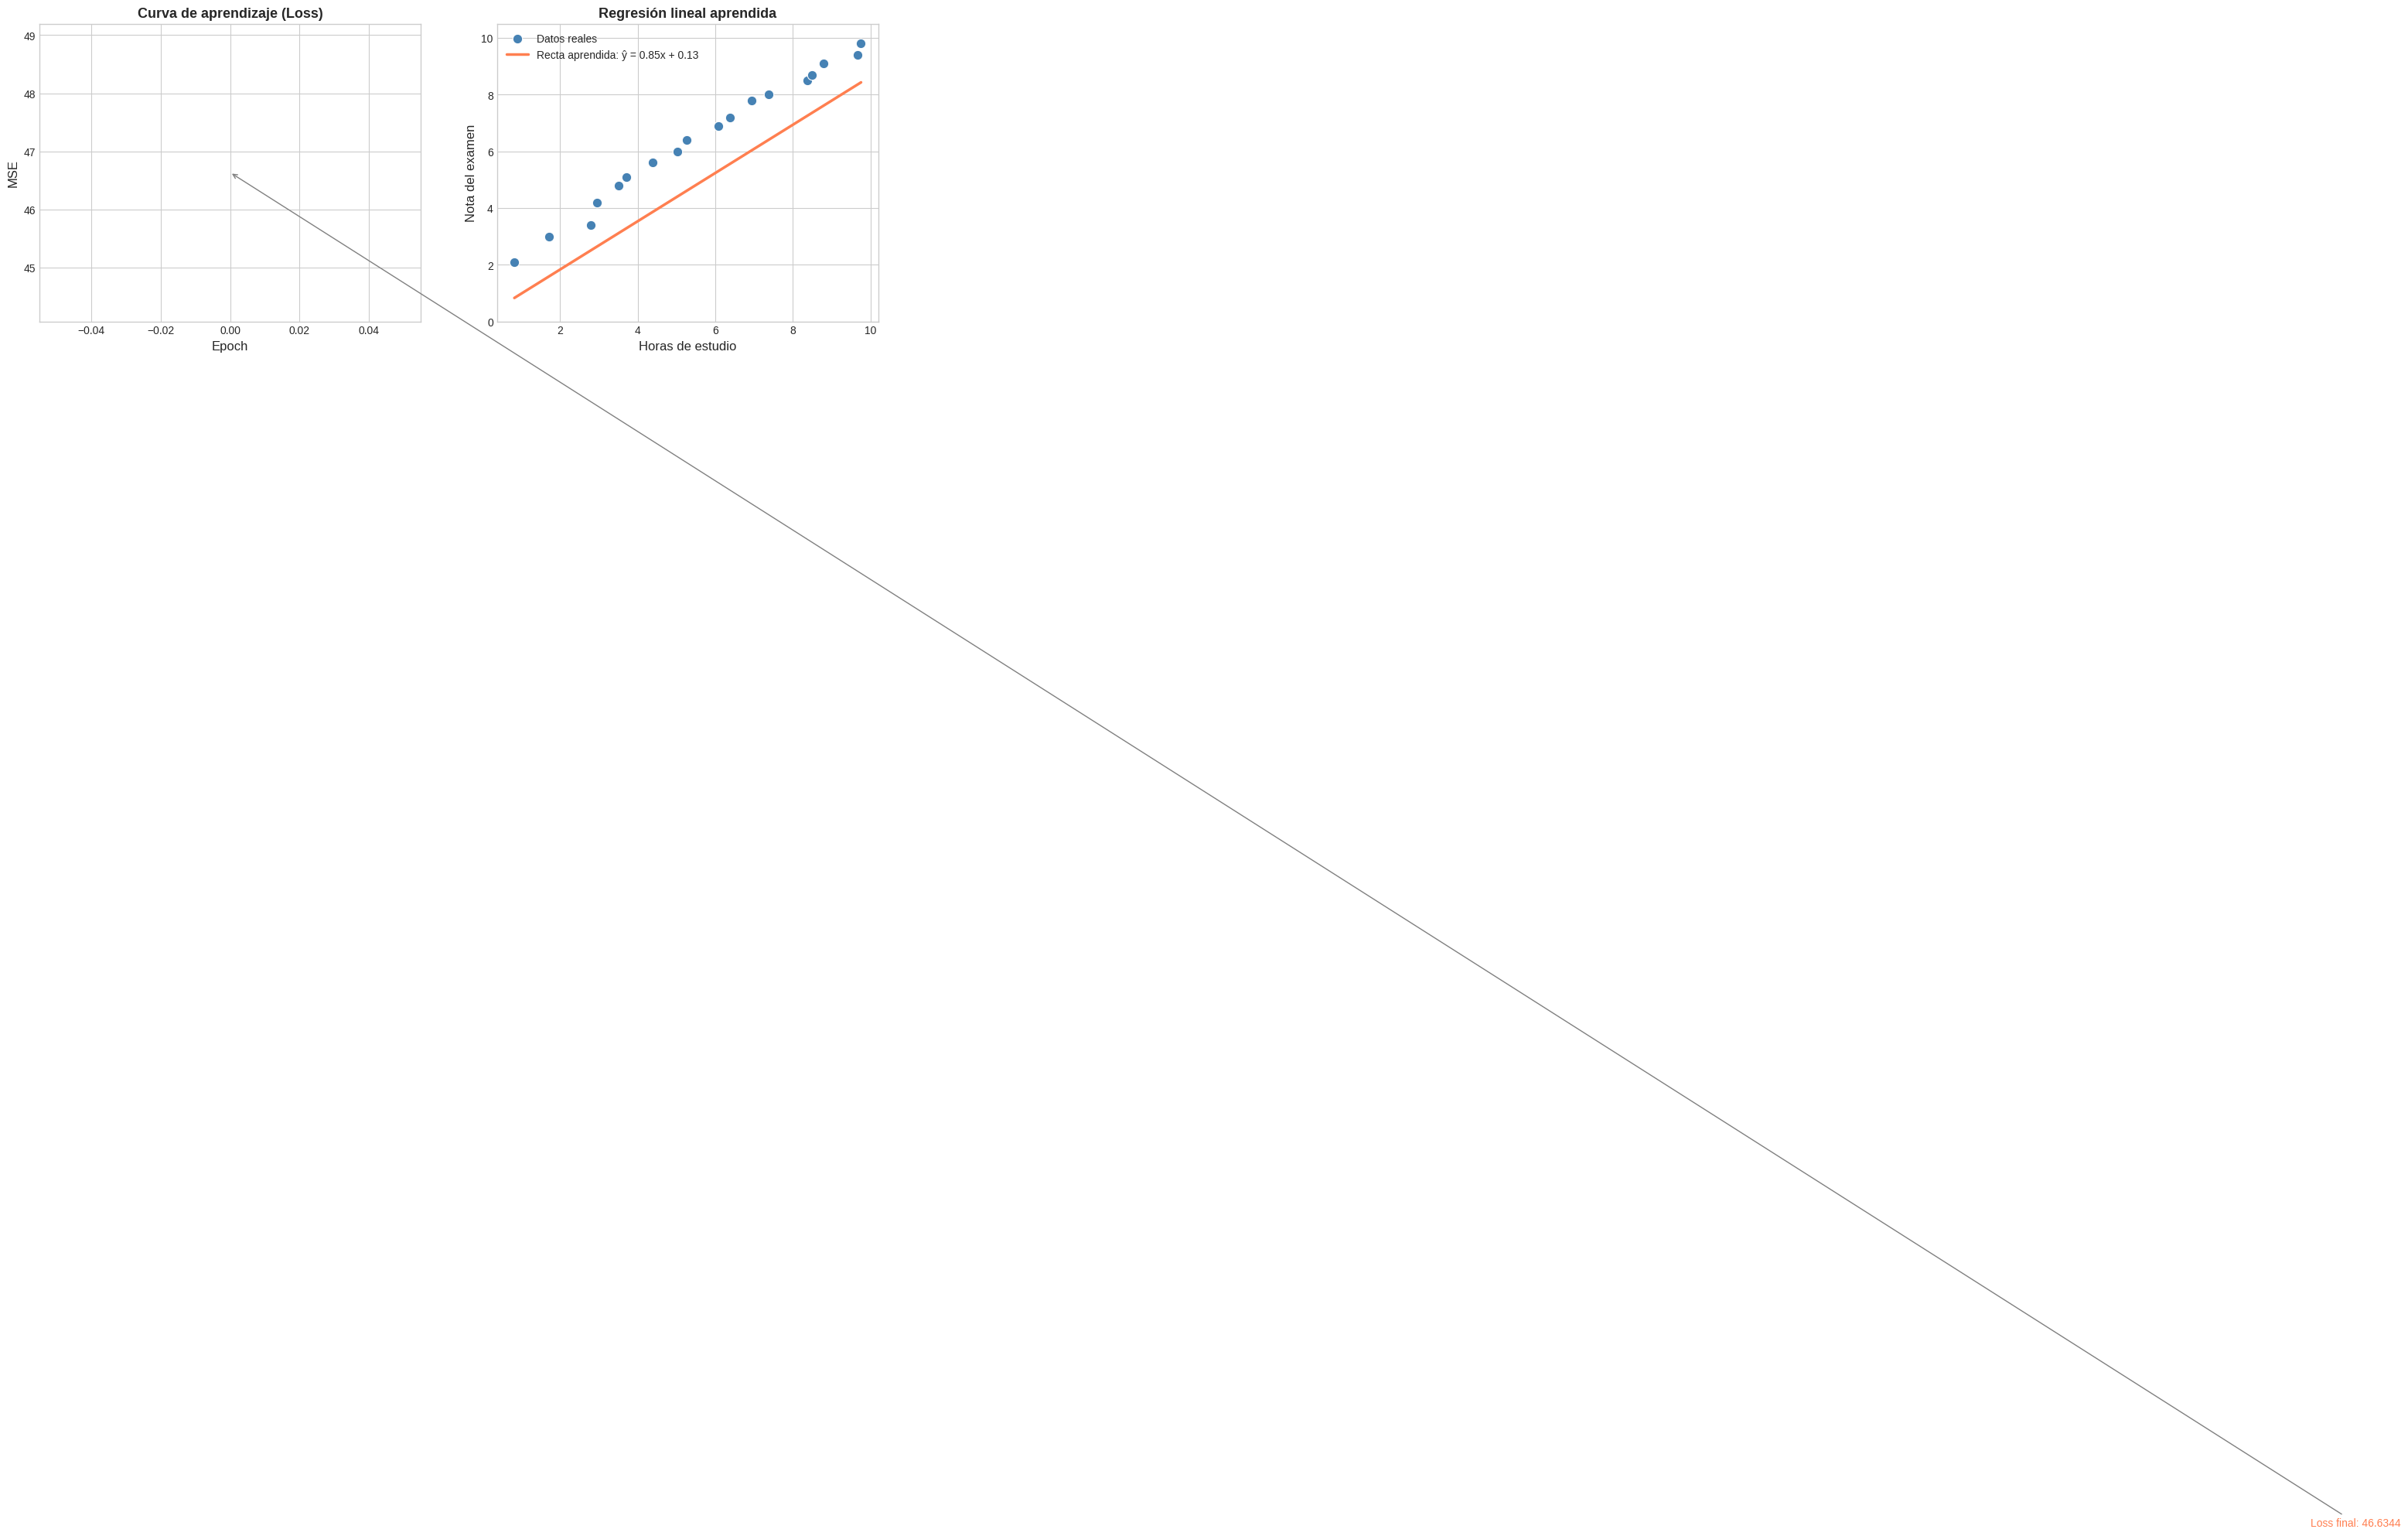

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva de loss ---
axes[0].plot(historial_loss, color='coral', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('Curva de aprendizaje (Loss)', fontsize=13, fontweight='bold')
axes[0].annotate(f'Loss final: {historial_loss[-1]:.4f}',
                 xy=(epochs-1, historial_loss[-1]),
                 xytext=(epochs*0.6, historial_loss[0]*0.5),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=10, color='coral')

# --- Datos + recta aprendida ---
x_line  = np.linspace(hours.min(), hours.max(), 100)
y_line  = predict(x_line, w, b)

axes[1].scatter(hours, grades, color='steelblue', s=80,
                edgecolors='white', linewidths=0.8, zorder=3, label='Datos reales')
axes[1].plot(x_line, y_line, color='coral', linewidth=2.5, label=f'Recta aprendida: ŷ = {w:.2f}x + {b:.2f}')
axes[1].set_xlabel('Horas de estudio', fontsize=12)
axes[1].set_ylabel('Nota del examen', fontsize=12)
axes[1].set_title('Regresión lineal aprendida', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 10.5)

plt.tight_layout()
plt.show()


In [47]:
def predict_grade(student_hours, w, b):
    nota = predict(student_hours, w, b)
    nota = np.clip(nota, 0, 10)
    print(f"Con {student_hours}h de estudio → Nota estimada: {nota:.2f}/10")
    return nota

predict_grade(3, w, b)
predict_grade(6, w, b)
predict_grade(9, w, b)


Con 3h de estudio → Nota estimada: 2.68/10
Con 6h de estudio → Nota estimada: 5.23/10
Con 9h de estudio → Nota estimada: 7.78/10


np.float64(7.784684916857944)

# 2️⃣ Parte 2 — Convertir a una Clase

Ahora encapsulamos toda la lógica en una clase `RegresionLineal`.
Esto nos permite:
- Reutilizar el código fácilmente
- Tener múltiples modelos independientes
- Seguir la misma interfaz que scikit-learn (fit / predict)

La interfaz será:
```python
modelo = RegresionLineal(learning_rate=0.01, epochs=1000)
modelo.fit(X, y)
y_pred = modelo.predict(X)

In [56]:
class RegresionLineal:
    """
    Regresión Lineal Simple con Gradient Descent.

    Parámetros
    ----------
    learning_rate : float - Tamaño del paso en cada actualización. Default 0.01.
    epochs : int - Número de iteraciones de entrenamiento. Default 1000.
    verbose : int - Cada cuántas epochs imprimir el loss. 0 = silencioso.

    Atributos aprendidos
    w_ : float  → pendiente
    b_ : float  → bias
    historial_loss_ : list → evolución del MSE durante el entrenamiento
    """

    def __init__(self, learning_rate=0.01, epochs=1000, verbose=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.verbose = verbose
        self.w_ = None
        self.b_ = None
        self.historial_loss_ = []

    def fit(self, x, y):
        """Entrena el modelo con los datos (x, y)."""
        self.w_ = 0.0
        self.b_ = 0.0
        self.historial_loss_ = []
        n = len(y)

        for epoch in range(self.epochs):
            y_pred = self._predecir(x)
            loss   = np.mean((y - y_pred) ** 2)
            self.historial_loss_.append(loss)

            # Gradientes
            error = y - y_pred
            dw    = (-2 / n) * np.sum(x * error)
            db    = (-2 / n) * np.sum(error)

            # Actualización
            self.w_ -= self.learning_rate * dw
            self.b_ -= self.learning_rate * db

            if self.verbose and epoch % self.verbose == 0:
                print(f"Epoch {epoch:4d} | MSE: {loss:.4f} | w: {self.w_:.4f} | b: {self.b_:.4f}")

        print(f"\n TRAINING FINISH")
        print(f"   w = {self.w_:.4f} | b = {self.b_:.4f} | MSE final = {self.historial_loss_[-1]:.4f}")
        return self

    def predict(self, x):
        """Devuelve predicciones para x."""
        self._check_fitted()
        return self._predecir(x)

    def score(self, x, y):
        """Devuelve R² (coeficiente de determinación)."""
        self._check_fitted()
        y_pred  = self.predict(x)
        ss_res  = np.sum((y - y_pred) ** 2)
        ss_tot  = np.sum((y - np.mean(y)) ** 2)
        r2      = 1 - (ss_res / ss_tot)
        print(f"R² = {r2:.4f}  ({r2*100:.1f}% de la varianza explicada)")
        return r2

    def plot(self, x, y, titulo="Regresión Lineal"):
        """Visualiza datos + recta + curva de loss."""
        self._check_fitted()
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Curva de loss
        axes[0].plot(self.historial_loss_, color='coral', linewidth=2)
        axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('MSE')
        axes[0].set_title('Curva de aprendizaje', fontweight='bold')

        # Datos + recta
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = self.predict(x_line)
        axes[1].scatter(x, y, color='steelblue', s=80, edgecolors='white', linewidths=0.8, zorder=3, label='Datos reales')
        axes[1].plot(x_line, y_line, color='coral', linewidth=2.5,
                     label=f'ŷ = {self.w_:.2f}x + {self.b_:.2f}')
        axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
        axes[1].set_title(titulo, fontweight='bold')
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    def _predecir(self, x):
        return self.w_ * x + self.b_

    def _check_fitted(self):
        if self.w_ is None:
            raise RuntimeError("El modelo no ha sido entrenado. Llama a .fit() primero.")


Epoch    0 | MSE: 46.6344 | w: 0.8506 | b: 0.1289

 TRAINING FINISH
   w = 1.0570 | b = 0.1862 | MSE final = 0.4684
R² = 0.9088  (90.9% de la varianza explicada)


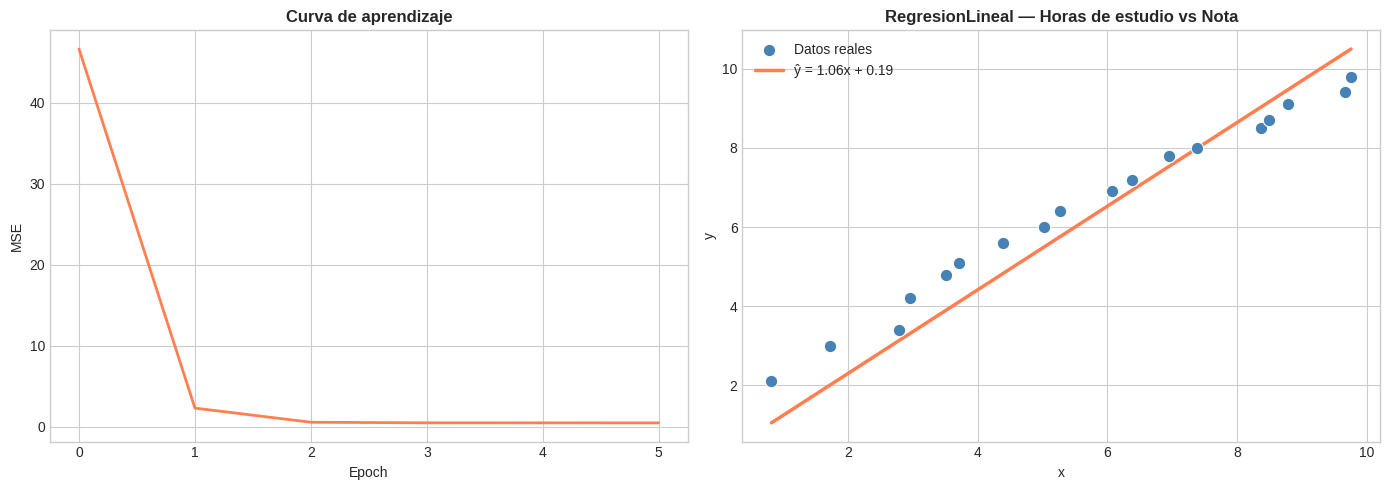

  2h de estudio → nota estimada: 2.30
  5h de estudio → nota estimada: 5.47
  8h de estudio → nota estimada: 8.64
  10h de estudio → nota estimada: 10.76


In [59]:
EPOCHS = 6

lr_model = RegresionLineal(learning_rate=0.01, epochs=EPOCHS, verbose=200)
lr_model.fit(hours, grades)
lr_model.score(hours, grades)
lr_model.plot(hours, grades, titulo="RegresionLineal — Horas de estudio vs Nota")

# Predicciones
for h in [2, 5, 8, 10]:
    pred = lr_model.predict(np.array([h]))[0]
    print(f"  {h}h de estudio → nota estimada: {pred:.2f}")

# 3️⃣ Parte 3 — Implementación con scikit-learn

En esta parte usamos **scikit-learn**, que implementa la solución **analítica** (método de los mínimos cuadrados ordinarios — *Ordinary Least Squares*, OLS) en lugar de Gradient Descent.

Ventajas principales:

- Solución **exacta** (no aproximada)
- No requiere elegir *learning rate* ni número de épocas
- Muy rápida para datasets pequeños/medianos
- Muy estable numéricamente

La fórmula cerrada para los parámetros óptimos es:

$$
w = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}
$$

$$
b = \bar{y} - w \cdot \bar{x}
$$

Donde:
- $\bar{x}$ = media de las $x$
- $\bar{y}$ = media de las $y$

La interfaz de scikit-learn es muy similar a la que implementamos manualmente: usamos `.fit()` y `.predict()`.



In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Train/test split — buena práctica evaluar en datos no vistos
X = hours.reshape(-1, 1)  # scikit-learn requiere shape (n, 1) para features
y = grades

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} muestras | Test: {len(X_test)} muestras")

# Entrenar
sk_modelo = LinearRegression()
sk_modelo.fit(X_train, y_train)

# Coeficientes aprendidos
print(f"\n Parámetros aprendidos por scikit-learn:")
print(f"   w (coef_)    = {sk_modelo.coef_[0]:.4f}")
print(f"   b (intercept_) = {sk_modelo.intercept_:.4f}")

# Nuestro modelo aprendió:
print(f"\n Parámetros aprendidos por nuestra clase:")
print(f"   w = {lr_model.w_:.4f}")
print(f"   b = {lr_model.b_:.4f}")

# Evaluación en test
y_pred_test = sk_modelo.predict(X_test)
mse_test    = mean_squared_error(y_test, y_pred_test)
r2_test     = r2_score(y_test, y_pred_test)

print(f"\n📊 Métricas en test set:")
print(f"   MSE = {mse_test:.4f}")
print(f"   R²  = {r2_test:.4f}  ({r2_test*100:.1f}% de la varianza explicada)")

Train: 14 muestras | Test: 4 muestras

 Parámetros aprendidos por scikit-learn:
   w (coef_)    = 0.8290
   b (intercept_) = 1.7397

 Parámetros aprendidos por nuestra clase:
   w = 1.0570
   b = 0.1862

📊 Métricas en test set:
   MSE = 0.0730
   R²  = 0.9746  (97.5% de la varianza explicada)


##PLOT

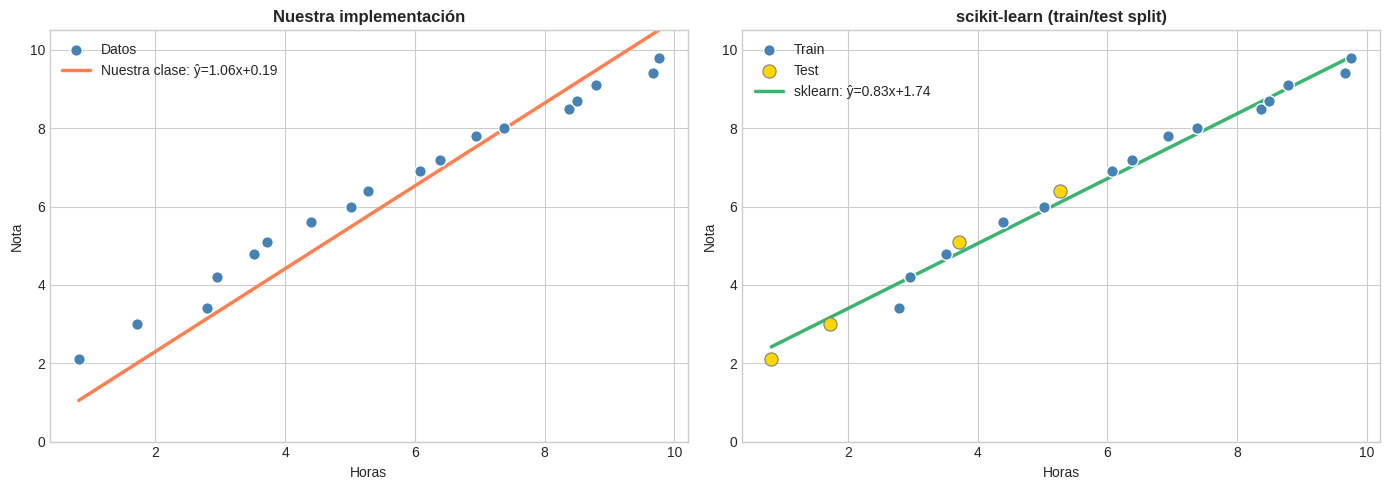

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)

# --- Nuestra implementación ---
axes[0].scatter(hours, grades, color='steelblue', s=70, edgecolors='white', zorder=3, label='Datos')
axes[0].plot(x_line, lr_model.predict(x_line.flatten()),
             color='coral', linewidth=2.5,
             label=f'Nuestra clase: ŷ={lr_model.w_:.2f}x+{lr_model.b_:.2f}')
axes[0].set_title('Nuestra implementación', fontweight='bold')
axes[0].set_xlabel('Horas'); axes[0].set_ylabel('Nota')
axes[0].legend(); axes[0].set_ylim(0, 10.5)

# --- scikit-learn ---
axes[1].scatter(X_train, y_train, color='steelblue', s=70, edgecolors='white', zorder=3, label='Train')
axes[1].scatter(X_test, y_test, color='gold', s=90, edgecolors='gray', linewidths=0.8, zorder=3, label='Test')
axes[1].plot(x_line, sk_modelo.predict(x_line),
             color='mediumseagreen', linewidth=2.5,
             label=f'sklearn: ŷ={sk_modelo.coef_[0]:.2f}x+{sk_modelo.intercept_:.2f}')
axes[1].set_title('scikit-learn (train/test split)', fontweight='bold')
axes[1].set_xlabel('Horas'); axes[1].set_ylabel('Nota')
axes[1].legend(); axes[1].set_ylim(0, 10.5)

plt.tight_layout()
plt.show()

# 4️⃣ Resumen y conceptos clave

| Concepto | Descripción |
|---|---|
| **w (peso / pendiente)** | Cuánto sube la nota por cada hora extra de estudio |
| **b (bias)** | Nota base cuando se estudian 0 horas |
| **MSE** | Penaliza errores grandes (los eleva al cuadrado) |
| **R²** | % de la variabilidad de y explicada por el modelo. 1.0 = perfecto |
| **Learning rate** | Demasiado alto → diverge. Demasiado bajo → converge muy lento |
| **Epochs** | Más epochs → mejor convergencia (hasta cierto punto) |
| **Gradient Descent** | Algoritmo iterativo para minimizar el error |
| **OLS (sklearn)** | Solución exacta sin iteraciones. Más rápida pero menos flexible |

### ¿Cuándo usar regresión lineal?
- La relación entre x e y es aproximadamente lineal
- Necesitas interpretabilidad (puedes leer los coeficientes)
- Es la primera baseline de cualquier problema de regresión

### Limitaciones
- Solo captura relaciones lineales
- Sensible a outliers (el MSE los amplifica)
- Asume que los errores son independientes y tienen varianza constante

## ¿Y si cambiamos el learning rate?


 TRAINING FINISH
   w = 1.0394 | b = 0.3082 | MSE final = 0.4024

 TRAINING FINISH
   w = 0.9167 | b = 1.1544 | MSE final = 0.1117

 TRAINING FINISH
   w = -375890567870094757653078754187753629143841209450539935240108658719667339009919320880327944092992372639763624459962103906957762975961013196685312.0000 | b = -54509511253959988090816351311103023018599678511332012238012303615274128622778727946248568831615073682648288693815731921045271680833419256791040.0000 | MSE final = 638644944624984931937701680634867936316877550438910936903037189467477481768105488961570034896242023841924415972342982946267937793365825663099338076277809999183066059460917736899778626420767726763957986716559847091613395447733978427694434262968548822123558656742607894083985724303705374720.0000

 TRAINING FINISH
   w = nan | b = nan | MSE final = nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1106/3024607185.py:34: RuntimeWarning: overflow encountered in square
  loss   = np.mean((y - y_pred) ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_1106/3024607185.py:43: RuntimeWarning: invalid value encountered in scalar subtract
  self.w_ -= self.learning_rate * dw


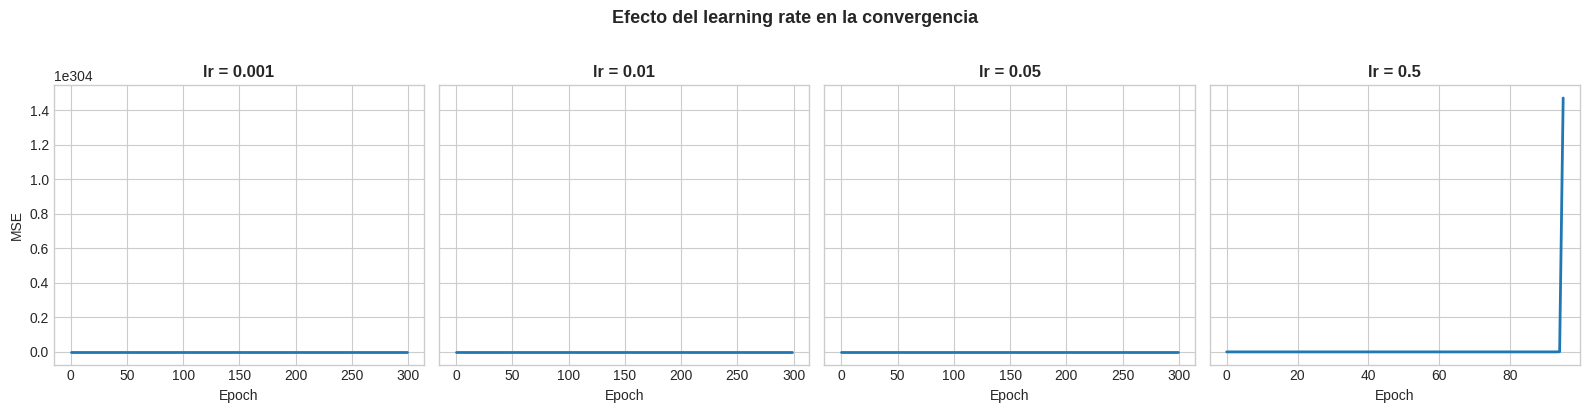

In [62]:
# BONUS — ¿Qué pasa si cambiamos el learning rate?

learning_rates = [0.001, 0.01, 0.05, 0.5]
fig, axes = plt.subplots(1, len(learning_rates), figsize=(16, 4), sharey=True)

for ax, lr in zip(axes, learning_rates):
    m = RegresionLineal(learning_rate=lr, epochs=300, verbose=0)
    m.fit(hours, grades)
    ax.plot(m.historial_loss_, linewidth=2)
    ax.set_title(f'lr = {lr}', fontweight='bold')
    ax.set_xlabel('Epoch')
    if ax == axes[0]: ax.set_ylabel('MSE')

plt.suptitle('Efecto del learning rate en la convergencia', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **Regresión Lineal — Ecuación Normal (Ordinary Least Squares)**

## ¿Qué es la Ecuación Normal?

Hasta ahora usábamos **Gradient Descent**: un proceso iterativo que va
ajustando $w$ y $b$ poco a poco hasta converger.

La **Ecuación Normal** (también llamada OLS — Ordinary Least Squares)
resuelve el problema de forma **exacta y directa**, en un solo paso,
sin epochs ni learning rate. Realmente, es la misma operación que usa `LinearRegression()` de **scikit-learn**, solo que OLS es el enfoque estadístico y la ecuación normal es el enfoque algebraico lineal. Lo que hace scikit-learn concretamente es llamar a `scipy.linalg.lstsq` , que a su vez usa descomposición SVD (Singular Value Decomposition) en lugar de invertir `XᵀX` directamente. Matemáticamente es equivalente, pero numéricamente más estable porque evitar invertir matrices es siempre preferible cuando hay alternativa.

## ¿Cómo funciona?

Queremos minimizar el MSE. Si tomamos la derivada del MSE respecto
a los pesos y la igualamos a cero, obtenemos la solución exacta:

$$\\hat{\\theta} = (X^T X)^{-1} X^T y$$

Donde:
- $X$ → matriz de features (con una columna de 1s para el bias)
- $y$ → vector de targets
- $\\hat{\\theta}$ → vector $[b, w]$ con los parámetros óptimos
- $X^T$ → transpuesta de X
- $(X^T X)^{-1}$ → inversa del producto

## Comparativa con Gradient Descent

| | Gradient Descent | Ecuación Normal |
|---|---|---|
| **Tipo** | Iterativo | Analítico (exacto) |
| **Hiperparámetros** | Learning rate, epochs | Ninguno |
| **Velocidad** | Lento en datasets grandes | Lento si hay muchas features (inversión de matriz) |
| **Escalabilidad** | Escala bien (mini-batch) | O(n³) — malo con miles de features |
| **Resultado** | Aproximado (converge) | Exacto |
| **Cuándo usarlo** | Muchas features, deep learning | Pocas features, datasets pequeños/medianos |

## Dataset

Usamos el mismo de antes: **Horas de estudio → Nota del examen**
para poder comparar los resultados directamente.
"""


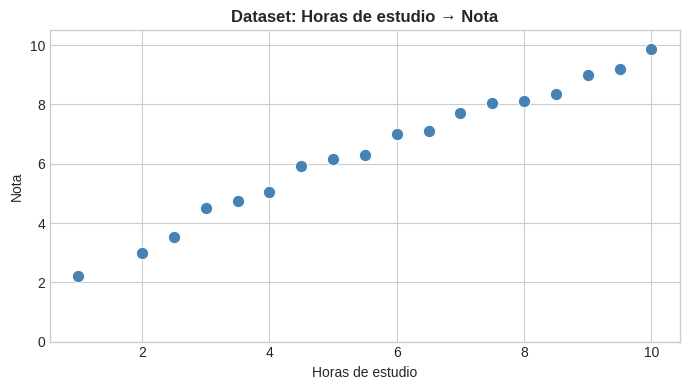

In [63]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# Dataset: horas de estudio → nota
horas = np.array([1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6,
                  6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10], dtype=float)
notas = np.array([2.1, 3.0, 3.4, 4.2, 4.8, 5.1, 5.6, 6.0, 6.4, 6.9,
                  7.2, 7.8, 8.0, 8.5, 8.7, 9.1, 9.4, 9.8], dtype=float)
notas += np.random.normal(0, 0.2, size=len(notas))
notas  = np.clip(notas, 0, 10)

plt.figure(figsize=(7, 4))
plt.scatter(horas, notas, color='steelblue', s=80, edgecolors='white', linewidths=0.8, zorder=3)
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Dataset: Horas de estudio → Nota', fontweight='bold')
plt.ylim(0, 10.5)
plt.tight_layout(); plt.show()

# 1️⃣ Paso a paso — Entendiendo la Ecuación Normal

La **ecuación normal** (Normal Equation) nos da la solución exacta de los parámetros óptimos de la regresión lineal mediante álgebra lineal, sin necesidad de iterar.

La fórmula es:

$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$

Donde:
- $\hat{\theta}$ → vector de parámetros óptimos $[b, w]^T$
- $X$ → matriz de características (con columna de 1s)
- $y$ → vector de valores objetivo
- $X^T$ → transpuesta de $X$
- $(X^T X)^{-1}$ → inversa de la matriz $X^T X$

Vamos a desglosarla paso a paso con un ejemplo intuitivo.

### **Paso 1** — Construir la matriz de diseño X (con columna de unos)

La columna de unos permite que el modelo calcule **automáticamente** tanto el intercepto ($b$) como la pendiente ($w$) en un solo vector $\theta = [b, w]^T$.

Para $n$ ejemplos, la matriz $X$ queda así:

$$
X = \begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\qquad
\theta = \begin{bmatrix} b \\ w \end{bmatrix}
\qquad
y = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}
$$

### Paso 2 — Ver cómo se genera la predicción

El producto matricial $X \theta$ produce directamente el vector de predicciones:

$$
X \theta = \begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b \\
w
\end{bmatrix}
=
\begin{bmatrix}
b + w \cdot x_1 \\
b + w \cdot x_2 \\
\vdots \\
b + w \cdot x_n
\end{bmatrix}
= \hat{y}
$$

Es decir: cada fila calcula $\hat{y}_i = b + w \cdot x_i$ de forma vectorizada.

### Paso 3 — ¿Por qué $(X^T X)^{-1} X^T y$ da la solución óptima?

- $X^T X$ → matriz cuadrada que contiene información de covarianza y varianza de las características
- $X^T y$ → producto que relaciona las características con los valores objetivo
- $(X^T X)^{-1} X^T y$ → minimiza el error cuadrático medio (es la solución analítica de mínimos cuadrados)

### Ejemplo numérico pequeño (para visualizar)

Supongamos 3 puntos:

| x (horas) | y (nota) |
|-----------|----------|
| 2         | 60       |
| 4         | 75       |
| 6         | 90       |

Entonces:

$$
X = \begin{bmatrix}
1 & 2 \\
1 & 4 \\
1 & 6
\end{bmatrix}, \quad
y = \begin{bmatrix}
60 \\
75 \\
90
\end{bmatrix}
$$

Puedes calcular manualmente (o con código):

1. $X^T X$
2. $(X^T X)^{-1}$
3. $X^T y$
4. $\hat{\theta} = (X^T X)^{-1} X^T y$

Y obtendrás aproximadamente: $b \approx 45$, $w \approx 7.5$



In [17]:
unos = np.ones((len(horas), 1))           # shape (18, 1)
X = np.column_stack([unos, horas])     # shape (18, 2)
y = notas                              # shape (18,)

print("Primeras filas de X (columna bias | columna horas):")
print(X[:5])
print(f"\nShape de X: {X.shape}  →  ({X.shape[0]} muestras, {X.shape[1]} columnas)")
print(f"Shape de y: {y.shape}")

Primeras filas de X (columna bias | columna horas):
[[1.  1. ]
 [1.  2. ]
 [1.  2.5]
 [1.  3. ]
 [1.  3.5]]

Shape de X: (18, 2)  →  (18 muestras, 2 columnas)
Shape de y: (18,)


## Paso 2 — Calcular $X^T X$

El producto $X^T X$ es una matriz cuadrada de tamaño (2×2), ya que tenemos dos parámetros a estimar: el intercepto $b$ y la pendiente $w$.

Su forma explícita es:

$$
X^T X = \begin{bmatrix}
n & \sum_{i=1}^n x_i \\
\sum_{i=1}^n x_i & \sum_{i=1}^n x_i^2
\end{bmatrix}
$$

### ¿Qué representa cada elemento?

| Posición       | Valor matemático          | Interpretación                              |
|----------------|----------------------------|---------------------------------------------|
| (1,1)          | $n$                        | Número total de observaciones (muestras)   |
| (1,2) y (2,1)  | $\sum x_i$                 | Suma de todas las variables de entrada $x$  |
| (2,2)          | $\sum x_i^2$               | Suma de los cuadrados de las $x$            |

Esta matriz $X^T X$ resume la **estructura y dispersión** de los datos de entrada:

- La diagonal captura la "magnitud" y "varianza" de las variables.
- Los elementos fuera de la diagonal capturan la relación entre la constante (unos) y la variable $x$.

En términos estadísticos, $X^T X$ es proporcional a la matriz de covarianza (no centrada) de las características extendidas.

### Ejemplo numérico (con los 3 puntos anteriores)

Recordemos los datos:

$$
X = \begin{bmatrix}
1 & 2 \\
1 & 4 \\
1 & 6
\end{bmatrix}
$$

Entonces:

- $n = 3$
- $\sum x_i = 2 + 4 + 6 = 12$
- $\sum x_i^2 = 4 + 16 + 36 = 56$

Por lo tanto:

$$
X^T X = \begin{bmatrix}
3 & 12 \\
12 & 56
\end{bmatrix}
$$

Este pequeño cálculo ya nos da toda la información necesaria para seguir con la ecuación normal.



In [66]:
unos = np.ones((len(horas), 1))           # shape (18, 1)
X    = np.column_stack([unos, horas])     # shape (18, 2)
y    = notas                              # shape (18,)

XtX = X.T @ X   # @ es el operador de multiplicación matricial en NumPy

print("X^T · X =")
print(XtX)
print(f"\nShape: {XtX.shape}  → matriz cuadrada (n_params × n_params)")
print(f"\nInterpretación:")
print(f"  [0,0] = n = {XtX[0,0]:.0f}  (número de muestras)")
print(f"  [0,1] = Σx  = {XtX[0,1]:.2f}  (suma de horas)")
print(f"  [1,1] = Σx² = {XtX[1,1]:.2f}  (suma de horas al cuadrado)")


X^T · X =
[[ 18. 103.]
 [103. 715.]]

Shape: (2, 2)  → matriz cuadrada (n_params × n_params)

Interpretación:
  [0,0] = n = 18  (número de muestras)
  [0,1] = Σx  = 103.00  (suma de horas)
  [1,1] = Σx² = 715.00  (suma de horas al cuadrado)


## Paso 3 — Calcular $(X^T X)^{-1}$

Ahora invertimos la matriz $X^T X$ para "despejar" los parámetros $\theta$ en la ecuación normal.

Es exactamente el equivalente matricial de la división en álgebra escalar:

- Si $a \cdot x = b \quad \Rightarrow \quad x = a^{-1} \cdot b$  
- Aquí: $(X^T X) \cdot \theta = X^T y \quad \Rightarrow \quad \theta = (X^T X)^{-1} \cdot X^T y$

### Fórmula completa hasta este punto

$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$

Invertir $X^T X$ es el paso clave que nos permite obtener la solución **exacta** de mínimos cuadrados en un solo cálculo (sin iteraciones).

### Advertencia importante

⚠️ La matriz $X^T X$ **debe ser invertible** para que la ecuación normal funcione.

$X^T X$ es **singular** (no invertible) cuando:

- Hay **multicolinealidad perfecta** entre las columnas de $X$  
  (ejemplo: una feature es exactamente el doble de otra, o una es combinación lineal perfecta de otras)
- Hay menos muestras que parámetros (muy pocos datos)
- Alguna columna de $X$ es idéntica a otra (incluyendo la columna de unos)

En estos casos, la inversa no existe y el cálculo falla.  
Solución habitual en la práctica:

- Usar la **pseudoinversa** de Moore-Penrose (`np.linalg.pinv()` en NumPy)
- Eliminar features redundantes
- Aplicar regularización (Ridge, Lasso) → que sí maneja multicolinealidad

### Ejemplo numérico (continuando con los datos anteriores)

Teníamos:

$$
X^T X = \begin{bmatrix}
3 & 12 \\
12 & 56
\end{bmatrix}
$$

Calculamos su inversa (lo hacemos a mano para entenderlo):

1. Determinante:  
   $\det(X^T X) = (3 \cdot 56) - (12 \cdot 12) = 168 - 144 = 24$

2. Matriz adjunta (transpuesta de cofactores):  
   $\begin{bmatrix} 56 & -12 \\ -12 & 3 \end{bmatrix}$

3. Inversa:  
   $(X^T X)^{-1} = \frac{1}{24} \begin{bmatrix} 56 & -12 \\ -12 & 3 \end{bmatrix} = \begin{bmatrix} 2.333 & -0.5 \\ -0.5 & 0.125 \end{bmatrix}$

Redondeado:

$$
(X^T X)^{-1} \approx \begin{bmatrix}
2.333 & -0.500 \\
-0.500 & 0.125
\end{bmatrix}
$$

(En la práctica nunca calculamos esto a mano → usamos `np.linalg.inv()` o `np.linalg.pinv()`)

En el siguiente paso multiplicaremos esta inversa por $X^T y$ para obtener finalmente $b$ y $w$.

¿Seguimos con el **Paso 4 — Calcular $X^T y$** y cerramos la ecuación normal?  
O prefieres ver ya el código completo en NumPy con estos mismos datos?

In [67]:
XtX_inv = np.linalg.inv(XtX)

print("(X^T · X)⁻¹ =")
print(XtX_inv)

# Verificación: A · A⁻¹ debe dar la identidad
identidad = XtX @ XtX_inv
print("\nVerificación — XtX · XtX_inv ≈ Identidad:")
print(np.round(identidad, 10))


(X^T · X)⁻¹ =
[[ 0.31623176 -0.04555506]
 [-0.04555506  0.00796108]]

Verificación — XtX · XtX_inv ≈ Identidad:
[[ 1. -0.]
 [-0.  1.]]


## Paso 4 — Calcular $X^T y$

Este paso calcula el vector $X^T y$, que captura la **relación lineal** (covarianza no centrada) entre cada columna de $X$ y el vector objetivo $y$.

Su forma explícita es:

$$
X^T y = \begin{bmatrix}
\sum_{i=1}^n y_i \\
\sum_{i=1}^n x_i y_i
\end{bmatrix}
$$

### ¿Qué significa cada componente?

| Posición | Valor matemático     | Interpretación                                      |
|----------|----------------------|-----------------------------------------------------|
| 1        | $\sum y_i$           | Suma total de las notas (target)                    |
| 2        | $\sum x_i y_i$       | Suma de los productos $x_i \cdot y_i$ → mide cuánto "co-varían" las horas de estudio con las notas |

Este vector es esencial: combina la información de los valores objetivo con la estructura de las características para "pesar" cuánto influye cada parámetro.

### Ejemplo numérico (continuando con los mismos datos)

Recordemos los puntos:

$$
X = \begin{bmatrix}
1 & 2 \\
1 & 4 \\
1 & 6
\end{bmatrix}, \quad
y = \begin{bmatrix}
60 \\
75 \\
90
\end{bmatrix}
$$

Calculamos:

- $\sum y_i = 60 + 75 + 90 = 225$
- $\sum x_i y_i = (2 \cdot 60) + (4 \cdot 75) + (6 \cdot 90) = 120 + 300 + 540 = 960$

Por lo tanto:

$$
X^T y = \begin{bmatrix}
225 \\
960
\end{bmatrix}
$$

### Paso final a la vista

Ya tenemos todo lo necesario:

- $(X^T X)^{-1} \approx \begin{bmatrix} 2.333 & -0.500 \\ -0.500 & 0.125 \end{bmatrix}$
- $X^T y = \begin{bmatrix} 225 \\ 960 \end{bmatrix}$

Multiplicamos:

$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$



In [20]:
Xty = X.T @ y

print("X^T · y =")
print(Xty)
print(f"\nInterpretación:")
print(f"  [0] = Σy    = {Xty[0]:.4f}  (suma de todas las notas)")
print(f"  [1] = Σ(xy) = {Xty[1]:.4f}  (suma de horas × nota)")

X^T · y =
[115.77887131 764.81072688]

Interpretación:
  [0] = Σy    = 115.7789  (suma de todas las notas)
  [1] = Σ(xy) = 764.8107  (suma de horas × nota)


## Paso 5 — Solución final: $\hat{\theta} = (X^T X)^{-1} X^T y$

Ahora solo queda multiplicar los dos resultados que ya calculamos:

- La inversa $(X^T X)^{-1}$
- El vector $X^T y$

Esto nos da directamente el vector de parámetros óptimos $\hat{\theta} = \begin{bmatrix} b \\ w \end{bmatrix}$.

### Cálculo con los datos del ejemplo

Recordemos lo que tenemos:

$$
(X^T X)^{-1} \approx \begin{bmatrix}
2.333 & -0.500 \\
-0.500 & 0.125
\end{bmatrix}
\qquad
X^T y = \begin{bmatrix}
225 \\
960
\end{bmatrix}
$$

Realizamos la multiplicación matricial:

$$
\hat{\theta} = \begin{bmatrix}
2.333 & -0.500 \\
-0.500 & 0.125
\end{bmatrix}
\begin{bmatrix}
225 \\
960
\end{bmatrix}
$$

Calculamos cada componente:

- Primer elemento (intercepto $b$):  
  $2.333 \cdot 225 + (-0.500) \cdot 960 = 525 - 480 = 45$

- Segundo elemento (pendiente $w$):  
  $-0.500 \cdot 225 + 0.125 \cdot 960 = -112.5 + 120 = 7.5$

Resultado final:

$$
\hat{\theta} = \begin{bmatrix}
45 \\
7.5
\end{bmatrix}
\quad \Rightarrow \quad
b = 45, \quad w = 7.5
$$

### Interpretación del resultado

La ecuación de la recta óptima es:

$$
\hat{y} = 7.5 \cdot x + 45
$$

- Cuando no has estudiado nada ($x = 0$) → el modelo predice una nota base de **45**
- Por cada hora adicional de estudio → la nota sube **7.5 puntos** en promedio

### Verificación rápida con los datos originales

| Horas (x) | Nota real (y) | Predicción ($\hat{y}$) | Error |
|-----------|---------------|--------------------------|-------|
| 2         | 60            | 7.5·2 + 45 = 60         | 0     |
| 4         | 75            | 7.5·4 + 45 = 75         | 0     |
| 6         | 90            | 7.5·6 + 45 = 90         | 0     |

En este caso particular los puntos estaban perfectamente alineados, por eso el error es exactamente 0 y $R^2 = 1$.  
En datasets reales suele haber algo de ruido y el ajuste no es perfecto.

### Resumen de toda la ecuación normal

1. Añadir columna de 1s → formar matriz $X$
2. Calcular $X^T X$
3. Invertir → $(X^T X)^{-1}$
4. Calcular $X^T y$
5. Multiplicar → $\hat{\theta} = (X^T X)^{-1} X^T y$

¡Y listo! Obtenemos la solución **exacta** de mínimos cuadrados en un solo paso (sin iteraciones ni learning rate).

En la práctica → usamos `numpy.linalg.inv()` o `numpy.linalg.pinv()` (más seguro) y todo se hace en 2–3 líneas.



In [70]:
theta = XtX_inv @ Xty   # shape (2,) → [b, w]

b_ols = theta[0]
w_ols = theta[1]

print("=" * 45)
print(f"  θ = (XᵀX)⁻¹ · Xᵀy")
print(f"  b (bias / intercept) = {b_ols:.6f}")
print(f"  w (peso / pendiente) = {w_ols:.6f}")
print("=" * 45)
print(f"\n  Ecuación aprendida: ŷ = {w_ols:.4f}·x + {b_ols:.4f}")
print(f"\n  Interpretación:")
print(f"  → Por cada hora extra de estudio, la nota sube {w_ols:.2f} puntos")
print(f"  → Con 0 horas de estudio, la nota estimada es {b_ols:.2f}")

  θ = (XᵀX)⁻¹ · Xᵀy
  b (bias / intercept) = 1.771954
  w (peso / pendiente) = 0.814405

  Ecuación aprendida: ŷ = 0.8144·x + 1.7720

  Interpretación:
  → Por cada hora extra de estudio, la nota sube 0.81 puntos
  → Con 0 horas de estudio, la nota estimada es 1.77


# 3️⃣ Encapsulado en una Clase

Misma interfaz `.fit()` / `.predict()` / `.score()` que antes,
pero ahora el entrenamiento es una sola línea de álgebra lineal.

Sin epochs. Sin learning rate. Sin historial de loss.

In [71]:
class RegresionLinealOLS:
    """
    Regresión Lineal mediante Ecuación Normal (OLS).
    Sin epochs. Sin learning rate. Sin historial de loss.
    """

    def __init__(self):
        self.w_ = None
        self.b_ = None

    def fit(self, x, y):
        """
        Calcula los parámetros óptimos con la ecuación normal.
        θ = (XᵀX)⁻¹ Xᵀy  (via pseudoinversa para mayor estabilidad)
        """
        X     = self._agregar_bias(x)
        theta = np.linalg.lstsq(X, y, rcond=None)[0]
        self.b_ = theta[0]
        self.w_ = theta[1]

        print(f"    OLS resuelto")
        print(f"   w = {self.w_:.6f} | b = {self.b_:.6f}")
        print(f"   Ecuación: ŷ = {self.w_:.4f}·x + {self.b_:.4f}")
        return self

    def predict(self, x):
        self._check_fitted()
        return self.w_ * x + self.b_

    def score(self, x, y):
        """R² — coeficiente de determinación."""
        self._check_fitted()
        y_pred = self.predict(x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot
        mse = np.mean((y - y_pred) ** 2)
        mae = np.mean(np.abs(y - y_pred))
        print(f"\n📊 Métricas:")
        print(f"   MSE = {mse:.4f}")
        print(f"   MAE = {mae:.4f}")
        print(f"   R²  = {r2:.4f}  ({r2*100:.1f}% varianza explicada)")
        return r2

    def plot(self, x, y, titulo="Regresión Lineal OLS"):
        self._check_fitted()
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = self.predict(x_line)
        y_pred = self.predict(x)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Recta ajustada con residuos ---
        axes[0].scatter(x, y, color='steelblue', s=80,
                        edgecolors='white', linewidths=0.8, zorder=3, label='Datos reales')
        axes[0].plot(x_line, y_line, color='coral', linewidth=2.5,
                     label=f'ŷ = {self.w_:.2f}x + {self.b_:.2f}')
        # Residuos
        for xi, yi, ypi in zip(x, y, y_pred):
            axes[0].plot([xi, xi], [yi, ypi], color='gray',
                         linewidth=0.8, linestyle='--', alpha=0.6)
        axes[0].set_xlabel('Horas de estudio'); axes[0].set_ylabel('Nota')
        axes[0].set_title(titulo, fontweight='bold')
        axes[0].legend(); axes[0].set_ylim(0, 10.5)

        # --- Residuos vs predicciones ---
        residuos = y - y_pred
        axes[1].scatter(y_pred, residuos, color='mediumseagreen', s=70,
                        edgecolors='white', linewidths=0.8, zorder=3)
        axes[1].axhline(0, color='coral', linewidth=1.5, linestyle='--')
        axes[1].set_xlabel('Predicción (ŷ)'); axes[1].set_ylabel('Residuo (y - ŷ)')
        axes[1].set_title('Análisis de residuos', fontweight='bold')

        plt.tight_layout(); plt.show()

    def _agregar_bias(self, x):
        unos = np.ones((len(x), 1))
        return np.column_stack([unos, x])

    def _check_fitted(self):
        if self.w_ is None:
            raise RuntimeError("Modelo no entrenado. Llama a .fit() primero.")

    OLS resuelto
   w = 0.814405 | b = 1.771954
   Ecuación: ŷ = 0.8144·x + 1.7720

📊 Métricas:
   MSE = 0.0725
   MAE = 0.2313
   R²  = 0.9846  (98.5% varianza explicada)


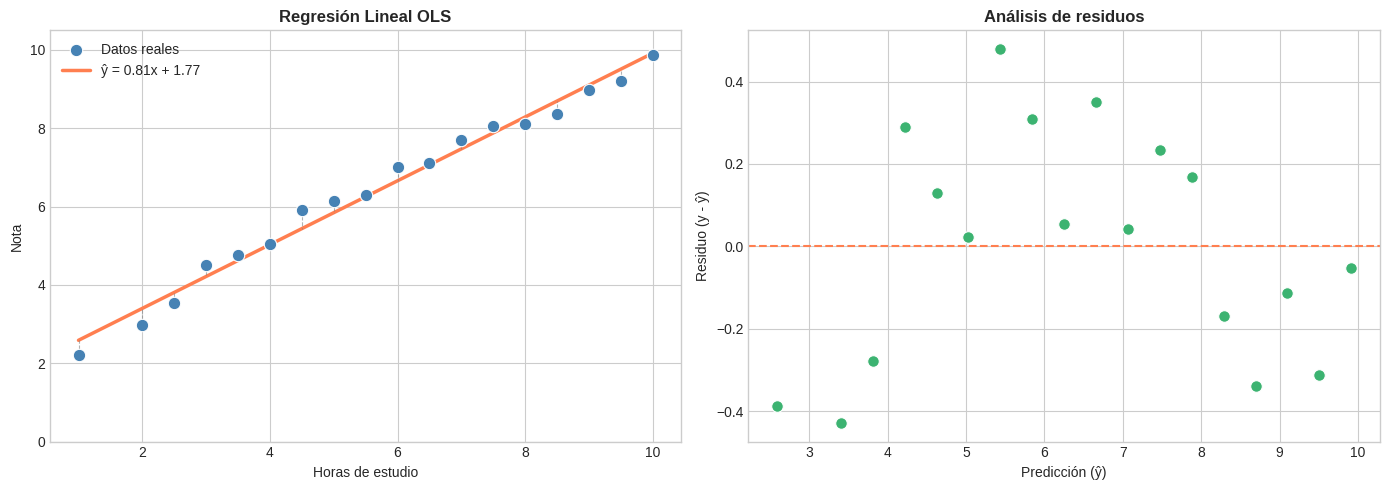

In [72]:
model_ols = RegresionLinealOLS()
model_ols.fit(horas, notas)
model_ols.score(horas, notas)
model_ols.plot(horas, notas)


# 4️⃣ Comparativa final — OLS vs Gradient Descent vs scikit-learn

Los tres métodos deben dar (casi) el mismo resultado.
- OLS y sklearn son exactos y deberían coincidir perfectamente.
- Gradient Descent es una aproximación que converge hacia ese valor.

Método                  w (pendiente)     b (bias)
OLS (nuestra clase)          0.814405     1.771954
scikit-learn                 0.814405     1.771954
Gradient Descent             0.814642     1.770314


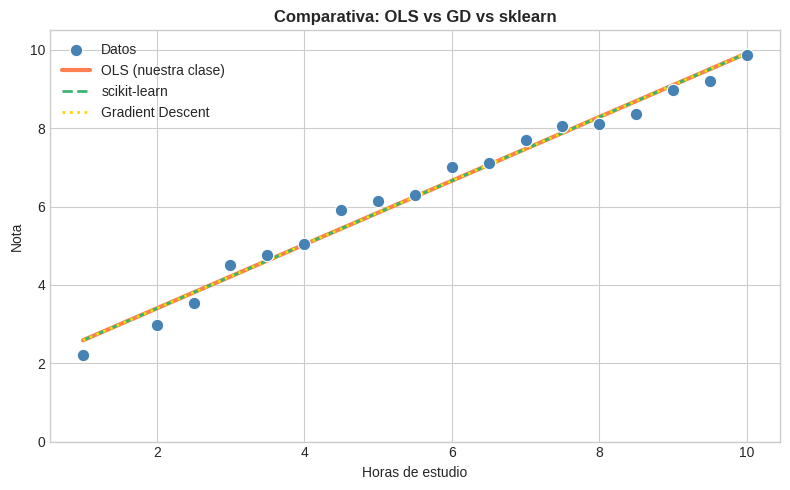

In [73]:
from sklearn.linear_model import LinearRegression

# sklearn
sk = LinearRegression()
sk.fit(horas.reshape(-1, 1), notas)

# Gradient Descent (implementación simple inline para comparar)
w_gd, b_gd = 0.0, 0.0
for _ in range(2000):
    y_p    = w_gd * horas + b_gd
    err    = notas - y_p
    w_gd  -= 0.01 * (-2 / len(horas)) * np.sum(horas * err)
    b_gd  -= 0.01 * (-2 / len(horas)) * np.sum(err)

print("=" * 52)
print(f"{'Método':<22} {'w (pendiente)':>14} {'b (bias)':>12}")
print("=" * 52)
print(f"{'OLS (nuestra clase)':<22} {model_ols.w_:>14.6f} {model_ols.b_:>12.6f}")
print(f"{'scikit-learn':<22} {sk.coef_[0]:>14.6f} {sk.intercept_:>12.6f}")
print(f"{'Gradient Descent':<22} {w_gd:>14.6f} {b_gd:>12.6f}")
print("=" * 52)

# Visualización comparativa
x_line = np.linspace(horas.min(), horas.max(), 100)
plt.figure(figsize=(8, 5))
plt.scatter(horas, notas, color='steelblue', s=80,
            edgecolors='white', linewidths=0.8, zorder=3, label='Datos')
plt.plot(x_line, model_ols.predict(x_line),
         color='coral',        linewidth=3,   linestyle='-',  label='OLS (nuestra clase)')
plt.plot(x_line, sk.predict(x_line.reshape(-1,1)),
         color='mediumseagreen', linewidth=2, linestyle='--', label='scikit-learn')
plt.plot(x_line, w_gd * x_line + b_gd,
         color='gold',         linewidth=2,   linestyle=':',  label='Gradient Descent')
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Comparativa: OLS vs GD vs sklearn', fontweight='bold')
plt.legend(); plt.ylim(0, 10.5)
plt.tight_layout(); plt.show()


# ✅ Resumen

| | OLS / Ecuación Normal | Gradient Descent |
|---|---|---|
| **Cómo funciona** | Una operación matricial exacta | Iteraciones que reducen el error |
| **Resultado** | Óptimo garantizado | Aproximado (depende de lr y epochs) |
| **Hiperparámetros** | Ninguno | Learning rate, epochs |
| **Complejidad** | O(n·p²) + O(p³) para la inversa | O(n·p) por iteración |
| **Cuándo falla** | Features colineales (matriz singular) | Learning rate mal elegido |
| **Cuándo usarlo** | p < 10.000 features | p muy grande, redes neuronales |

### La fórmula en una línea de NumPy
```python
theta = np.linalg.lstsq(X, y, rcond=None)[0]
```
Eso es todo. Detrás hay álgebra lineal pura:
derivar el MSE → igualarlo a cero → despejar θ → solución exacta.

# 5️⃣ Métricas de evaluación

Las métricas nos ayudan a cuantificar **qué tan bueno es nuestro modelo** y a comparar diferentes enfoques. Cada una mide el error desde un ángulo distinto.

### Tabla comparativa de métricas principales

| Métrica       | Fórmula                                                                 | Interpreta el error como              | Unidad                  | Sensible a outliers | Cuándo usarla principalmente                  |
|---------------|-------------------------------------------------------------------------|---------------------------------------|-------------------------|---------------------|-----------------------------------------------|
| **MAE**       | $\frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$                              | Promedio de errores absolutos         | Mismas que $y$          | No                  | Cuando quieres robustez frente a outliers     |
| **MSE**       | $\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$                          | Promedio de errores al cuadrado       | Cuadrado de las de $y$  | Sí (mucho)          | Base para muchas optimizaciones (pérdida)     |
| **RMSE**      | $\sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$      | Error típico en las mismas unidades   | Mismas que $y$          | Sí                  | La más interpretable junto con MAE            |
| **R²** (coef. determinación) | $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ = $1 - \frac{\text{SS}_{res}}{\text{SS}_{tot}}$ | Proporción de varianza explicada      | Entre 0 y 1 (o negativo) | No                  | Evaluar cuánto explica el modelo (ajuste global) |
| **Adjusted R²** | $1 - \left(1 - R^2\right) \frac{n-1}{n-p-1}$                          | R² penalizado por número de variables | Entre 0 y 1             | No                  | Cuando comparas modelos con distinto nº features |
| **MAPE**      | $\frac{100}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|$ | Error relativo promedio (en %)        | Porcentaje (%)          | No (pero sensible a $y_i \approx 0$) | Series temporales, forecasting con escala variable |
| **Max Error** | $\max_i |y_i - \hat{y}_i|$                                             | El peor error absoluto posible        | Mismas que $y$          | Totalmente          | Cuando el peor caso es crítico (seguridad, etc.) |

### Cómo interpretar R² de forma práctica

- **R² = 1.0** → Ajuste perfecto (el modelo explica toda la variabilidad de los datos)
- **R² = 0.90–0.99** → Muy buen modelo (explica 90–99 % de la varianza)
- **R² = 0.70–0.89** → Buen ajuste (común en ciencias sociales o datos ruidosos)
- **R² = 0.50–0.69** → Ajuste moderado (puede ser aceptable dependiendo del dominio)
- **R² < 0.5** → El modelo explica poco (mediocre o pobre)
- **R² ≤ 0** → El modelo es peor que simplemente predecir siempre la media de $y$ (muy malo)




In [74]:
def calculate_metrics(y_real, y_pred, nombre_modelo="Modelo"):
    """Calcula y muestra todas las métricas de regresión."""
    n  = len(y_real)
    error = y_real - y_pred
    mae = np.mean(np.abs(error))
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    r2 = 1 - ss_res / ss_tot
    mape = np.mean(np.abs(error / y_real)) * 100
    max_err = np.max(np.abs(error))

    print(f"\n{'='*45}")
    print(f"  📊 Métricas — {nombre_modelo}")
    print(f"{'='*45}")
    print(f"  MAE       = {mae:.4f}   (error medio absoluto)")
    print(f"  MSE       = {mse:.4f}   (error cuadrático medio)")
    print(f"  RMSE      = {rmse:.4f}   (raíz del MSE, mismas unidades que y)")
    print(f"  R²        = {r2:.4f}   ({r2*100:.1f}% varianza explicada)")
    print(f"  MAPE      = {mape:.2f}%    (error relativo medio)")
    print(f"  Max Error = {max_err:.4f}   (peor predicción)")
    print(f"{'='*45}")

    return {"MAE": mae, "MSE": mse, "RMSE": rmse,
            "R2": r2, "MAPE": mape, "MaxError": max_err}


# --- Calcular métricas para nuestro modelo OLS ---
y_pred_ols = model_ols.predict(horas)
metricas   = calculate_metrics(notas, y_pred_ols, "RegresionLinealOLS")


  📊 Métricas — RegresionLinealOLS
  MAE       = 0.2313   (error medio absoluto)
  MSE       = 0.0725   (error cuadrático medio)
  RMSE      = 0.2692   (raíz del MSE, mismas unidades que y)
  R²        = 0.9846   (98.5% varianza explicada)
  MAPE      = 4.76%    (error relativo medio)
  Max Error = 0.4791   (peor predicción)


# Visualización completa de métricas

Cuatro gráficas que juntas dan una imagen completa del comportamiento del modelo:

1. **Datos + recta** — visión general del ajuste
2. **Predicho vs Real** — los puntos deberían estar sobre la diagonal
3. **Residuos vs Predicho** — deberían estar dispersos alrededor del 0 sin patrón
4. **Histograma de residuos** — deberían seguir una distribución normal centrada en 0

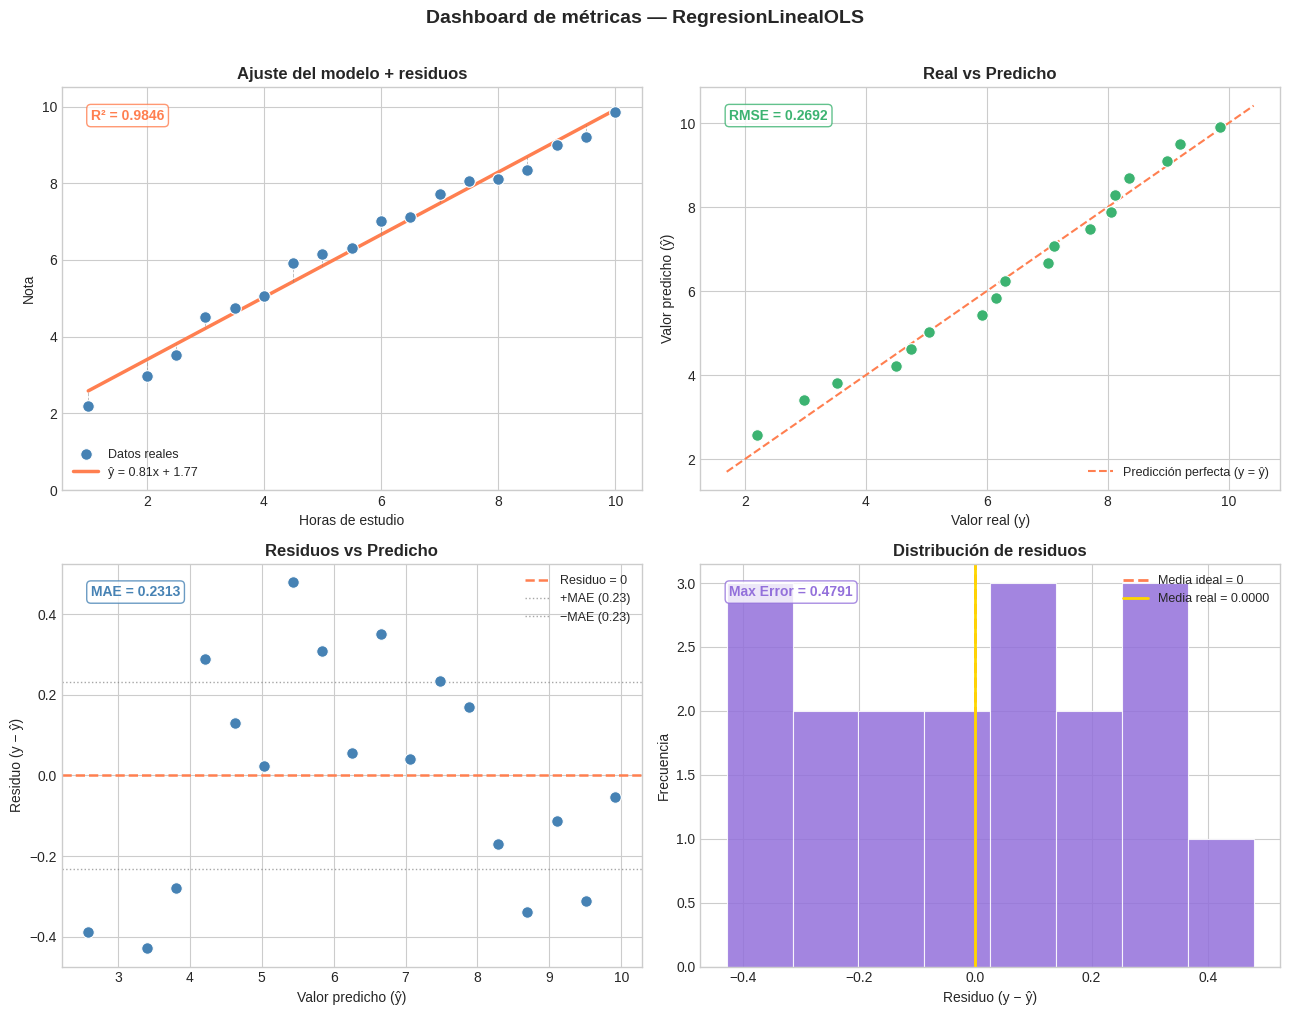


💡 Qué buscar en cada gráfica:
  1. Recta ajustada  → los puntos deben estar cerca de la línea
  2. Real vs Predicho → los puntos deben estar sobre la diagonal
  3. Residuos        → sin patrones (curvas = relación no lineal)
  4. Histograma      → campana centrada en 0 = errores aleatorios ✅


In [75]:
y_pred_ols = model_ols.predict(horas)
residuos   = notas - y_pred_ols

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Dashboard de métricas — RegresionLinealOLS', fontsize=14, fontweight='bold', y=1.01)

# --- 1. Datos + recta ajustada ---
ax = axes[0, 0]
x_line = np.linspace(horas.min(), horas.max(), 100)
ax.scatter(horas, notas, color='steelblue', s=70, edgecolors='white', linewidths=0.8, zorder=3, label='Datos reales')
ax.plot(x_line, model_ols.predict(x_line), color='coral', linewidth=2.5,
        label=f'ŷ = {model_ols.w_:.2f}x + {model_ols.b_:.2f}')
for xi, yi, ypi in zip(horas, notas, y_pred_ols):
    ax.plot([xi, xi], [yi, ypi], color='gray', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_title('Ajuste del modelo + residuos', fontweight='bold')
ax.set_xlabel('Horas de estudio'); ax.set_ylabel('Nota')
ax.legend(fontsize=9); ax.set_ylim(0, 10.5)

# Añadir R² como anotación
ax.text(0.05, 0.92, f'R² = {metricas["R2"]:.4f}', transform=ax.transAxes,
        fontsize=10, color='coral', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='coral', alpha=0.8))

# --- 2. Predicho vs Real ---
ax = axes[0, 1]
lim_min = min(notas.min(), y_pred_ols.min()) - 0.5
lim_max = max(notas.max(), y_pred_ols.max()) + 0.5
ax.scatter(notas, y_pred_ols, color='mediumseagreen', s=70, edgecolors='white', linewidths=0.8, zorder=3)
ax.plot([lim_min, lim_max], [lim_min, lim_max], color='coral', linewidth=1.5,
        linestyle='--', label='Predicción perfecta (y = ŷ)')
ax.set_title('Real vs Predicho', fontweight='bold')
ax.set_xlabel('Valor real (y)'); ax.set_ylabel('Valor predicho (ŷ)')
ax.legend(fontsize=9)
ax.text(0.05, 0.92, f'RMSE = {metricas["RMSE"]:.4f}', transform=ax.transAxes,
        fontsize=10, color='mediumseagreen', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='mediumseagreen', alpha=0.8))

# --- 3. Residuos vs Predicho ---
ax = axes[1, 0]
ax.scatter(y_pred_ols, residuos, color='steelblue', s=70, edgecolors='white', linewidths=0.8, zorder=3)
ax.axhline(0, color='coral', linewidth=1.8, linestyle='--', label='Residuo = 0')
ax.axhline( metricas["MAE"], color='gray', linewidth=1, linestyle=':', alpha=0.7, label=f'+MAE ({metricas["MAE"]:.2f})')
ax.axhline(-metricas["MAE"], color='gray', linewidth=1, linestyle=':', alpha=0.7, label=f'−MAE ({metricas["MAE"]:.2f})')
ax.set_title('Residuos vs Predicho', fontweight='bold')
ax.set_xlabel('Valor predicho (ŷ)'); ax.set_ylabel('Residuo (y − ŷ)')
ax.legend(fontsize=9)
ax.text(0.05, 0.92, f'MAE = {metricas["MAE"]:.4f}', transform=ax.transAxes,
        fontsize=10, color='steelblue', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='steelblue', alpha=0.8))

# --- 4. Histograma de residuos ---
ax = axes[1, 1]
ax.hist(residuos, bins=8, color='mediumpurple', edgecolor='white', linewidth=0.8, alpha=0.85)
ax.axvline(0, color='coral', linewidth=2, linestyle='--', label='Media ideal = 0')
ax.axvline(residuos.mean(), color='gold', linewidth=2, linestyle='-',
           label=f'Media real = {residuos.mean():.4f}')
ax.set_title('Distribución de residuos', fontweight='bold')
ax.set_xlabel('Residuo (y − ŷ)'); ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.text(0.05, 0.92, f'Max Error = {metricas["MaxError"]:.4f}', transform=ax.transAxes,
        fontsize=10, color='mediumpurple', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='mediumpurple', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n💡 Qué buscar en cada gráfica:")
print("  1. Recta ajustada  → los puntos deben estar cerca de la línea")
print("  2. Real vs Predicho → los puntos deben estar sobre la diagonal")
print("  3. Residuos        → sin patrones (curvas = relación no lineal)")
print("  4. Histograma      → campana centrada en 0 = errores aleatorios ✅")

# ✅ Resumen

| | OLS / Ecuación Normal | Gradient Descent |
|---|---|---|
| **Cómo funciona** | Una operación matricial exacta | Iteraciones que reducen el error |
| **Resultado** | Óptimo garantizado | Aproximado (depende de lr y epochs) |
| **Hiperparámetros** | Ninguno | Learning rate, epochs |
| **Complejidad** | O(n·p²) + O(p³) para la inversa | O(n·p) por iteración |
| **Cuándo falla** | Features colineales (matriz singular) | Learning rate mal elegido |
| **Cuándo usarlo** | p < 10.000 features | p muy grande, redes neuronales |

### La fórmula en una línea de NumPy
```python
theta = np.linalg.lstsq(X, y, rcond=None)[0]


# 6️⃣ Entrenamiento extendido, convergencia del Loss y serialización

Ahora vamos a:
1. Entrenar nuestra clase con **más iteraciones** y ver cómo converge el loss
2. Visualizar la **curva de convergencia** con zoom en la zona de estabilización
3. **Serializar el modelo** con `joblib` para dejarlo listo para producción
4. **Cargarlo y usarlo** como si fuera un servicio real

### ¿Qué es serializar un modelo?

Serializar = guardar el estado del modelo (sus parámetros aprendidos) en un archivo
para poder cargarlo después sin reentrenar. En producción es fundamental:
entrenas una vez, sirves millones de veces.

```
ENTRENAMIENTO          SERIALIZACIÓN         PRODUCCIÓN
┌─────────────┐        ┌──────────┐        ┌──────────────┐
│  fit(X, y)  │──────▶│  .joblib │──────▶│  predict(x)  │
│  w, b       │        │  archivo │        │  sin reentrenar│
└─────────────┘        └──────────┘        └──────────────┘
```
"""

In [77]:
class RegresionLinealGD:
    """
    Regresión Lineal con Gradient Descent.
    Guarda historial de loss para analizar convergencia.
    Compatible con joblib para serialización.
    """

    def __init__(self, learning_rate=0.01, epochs=5000, verbose=500):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.verbose = verbose
        self.w_ = None
        self.b_ = None
        self.historial_loss_ = []
        self.n_iter_ = 0

    def fit(self, x, y):
        self.w_ = 0.0
        self.b_ = 0.0
        self.historial_loss_ = []
        n = len(y)

        for epoch in range(self.epochs):
            y_pred = self._predict(x)
            loss = np.mean((y - y_pred) ** 2)
            self.historial_loss_.append(loss)

            error = y - y_pred
            dw = (-2 / n) * np.sum(x * error)
            db = (-2 / n) * np.sum(error)

            self.w_ -= self.learning_rate * dw
            self.b_ -= self.learning_rate * db

            if self.verbose and epoch % self.verbose == 0:
                delta = ""
                if epoch > 0:
                    caida = self.historial_loss_[-2] - loss
                    delta = f" | Δloss: -{caida:.6f}"
                print(f"  Epoch {epoch:5d} | Loss: {loss:.6f} | w: {self.w_:.4f} | b: {self.b_:.4f}{delta}")

        self.n_iter_ = self.epochs
        print(f"\n TRAINING FINISH ({self.epochs} epochs)")
        print(f"   w = {self.w_:.6f} | b = {self.b_:.6f}")
        print(f"   Loss inicial : {self.historial_loss_[0]:.6f}")
        print(f"   Loss final   : {self.historial_loss_[-1]:.6f}")
        print(f"   Reducción    : {((self.historial_loss_[0] - self.historial_loss_[-1]) / self.historial_loss_[0] * 100):.1f}%")
        return self

    def predict(self, x):
        self._check_fitted()
        return self._predict(x)

    def score(self, x, y):
        self._check_fitted()
        y_pred = self.predict(x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

    def _predict(self, x):
        return self.w_ * x + self.b_

    def _check_fitted(self):
        if self.w_ is None:
            raise RuntimeError("Modelo no entrenado. Llama a .fit() primero.")


# Entrenar con muchas iteraciones
modelo_gd = RegresionLinealGD(learning_rate=0.01, epochs=1000, verbose=1000)
modelo_gd.fit(horas, notas)

r2 = modelo_gd.score(horas, notas)
print(f"\n   R² = {r2:.6f}")


  Epoch     0 | Loss: 46.073627 | w: 0.8498 | b: 0.1286

 TRAINING FINISH (1000 epochs)
   w = 0.821863 | b = 1.720406
   Loss inicial : 46.073627
   Loss final   : 0.072964
   Reducción    : 99.8%

   R² = 0.984480


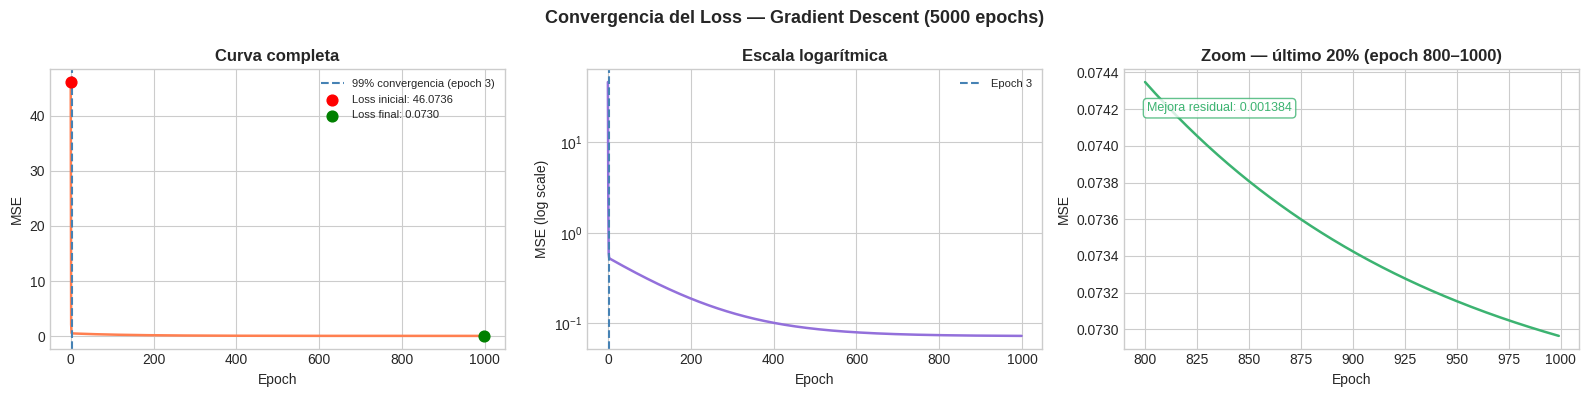


 El 99% de la mejora ocurre antes del epoch 3
   Las 997 epochs restantes apenas aportan


In [78]:
loss_arr = np.array(modelo_gd.historial_loss_)
epochs_x = np.arange(len(loss_arr))

# Calcular epoch de convergencia práctica (99% de mejora alcanzada)
mejora_total  = loss_arr[0] - loss_arr[-1]
umbral_99     = loss_arr[0] - 0.99 * mejora_total
epoch_conv    = np.argmax(loss_arr <= umbral_99)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Convergencia del Loss — Gradient Descent (5000 epochs)',
             fontsize=13, fontweight='bold')

# --- 1. Curva completa ---
ax = axes[0]
ax.plot(epochs_x, loss_arr, color='coral', linewidth=1.8)
ax.axvline(epoch_conv, color='steelblue', linewidth=1.5, linestyle='--',
           label=f'99% convergencia (epoch {epoch_conv})')
ax.scatter([0], [loss_arr[0]], color='red', s=60, zorder=5, label=f'Loss inicial: {loss_arr[0]:.4f}')
ax.scatter([len(loss_arr)-1], [loss_arr[-1]], color='green', s=60, zorder=5, label=f'Loss final: {loss_arr[-1]:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Curva completa', fontweight='bold')
ax.legend(fontsize=8)

# --- 2. Escala logarítmica ---
ax = axes[1]
ax.plot(epochs_x, loss_arr, color='mediumpurple', linewidth=1.8)
ax.set_yscale('log')
ax.axvline(epoch_conv, color='steelblue', linewidth=1.5, linestyle='--',
           label=f'Epoch {epoch_conv}')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log scale)')
ax.set_title('Escala logarítmica', fontweight='bold')
ax.legend(fontsize=8)

# --- 3. Zoom en la cola (último 20%) ---
ax      = axes[2]
inicio  = int(len(loss_arr) * 0.8)
ax.plot(epochs_x[inicio:], loss_arr[inicio:], color='mediumseagreen', linewidth=1.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title(f'Zoom — último 20% (epoch {inicio}–{len(loss_arr)})', fontweight='bold')
variacion = loss_arr[inicio] - loss_arr[-1]
ax.text(0.05, 0.85, f'Mejora residual: {variacion:.6f}',
        transform=ax.transAxes, fontsize=9, color='mediumseagreen',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='mediumseagreen', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n El 99% de la mejora ocurre antes del epoch {epoch_conv}")
print(f"   Las {modelo_gd.epochs - epoch_conv} epochs restantes apenas aportan")

#Serializar el modelo

# Función de inferencia lista para producción

En producción no exponemos el modelo directamente.
Lo envolvemos en una función que valida la entrada, predice y devuelve
un resultado estructurado — igual que haría una API REST.

In [80]:
import joblib
import os

# Save
ruta_modelo = "modelo_regresion_lineal.joblib"
joblib.dump(modelo_gd, ruta_modelo)
tamaño_kb   = os.path.getsize(ruta_modelo) / 1024
print(f"  Modelo guardado en: '{ruta_modelo}'")
print(f"   Tamaño en disco: {tamaño_kb:.2f} KB")

# load
load = joblib.load(ruta_modelo)
print(f"\n Modelo cargado correctamente")
print(f"   Tipo    : {type(load).__name__}")
print(f"   w       : {load.w_:.6f}")
print(f"   b       : {load.b_:.6f}")
print(f"   Epochs  : {load.n_iter_}")
print(f"   Historial: {len(load.historial_loss_)} puntos de loss guardados")

# --- Verificar que produce las mismas predicciones ---
casos_test = np.array([2.0, 5.0, 7.5, 10.0])
pred_original = modelo_gd.predict(casos_test)
pred_cargado  = load.predict(casos_test)

print(f"\n Verificación — predicciones idénticas tras carga:")
print(f"   {'Horas':>6} | {'Original':>10} | {'Cargado':>10} | {'Diferencia':>12}")
print(f"   {'-'*46}")
for h, po, pc in zip(casos_test, pred_original, pred_cargado):
    diff = abs(po - pc)
    print(f"   {h:>6.1f} | {po:>10.6f} | {pc:>10.6f} | {diff:>12.2e}")

def load_model(ruta: str):
    """Carga el modelo serializado desde disco."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró el modelo en: {ruta}")
    modelo = joblib.load(ruta)
    print(f" Modelo '{ruta}' cargado | w={modelo.w_:.4f} | b={modelo.b_:.4f}")
    return modelo


def predecir_nota(horas_estudio, modelo, min_val=0.0, max_val=10.0) -> dict:
    # Validación de entrada
    x = np.atleast_1d(np.array(horas_estudio, dtype=float))
    if np.any(x < 0):
        raise ValueError("Las horas de estudio no pueden ser negativas.")
    if np.any(x > 24):
        raise ValueError("Las horas de estudio no pueden superar 24h/día.")


    y_pred = modelo.predict(x)
    y_clip = np.clip(y_pred, min_val, max_val)

    return {
        "input_horas"  : x.tolist(),
        "prediccion"   : np.round(y_clip, 4).tolist(),
        "modelo_w"     : round(modelo.w_, 6),
        "modelo_b"     : round(modelo.b_, 6),
        "epochs"       : modelo.n_iter_,
        "loss_final"   : round(modelo.historial_loss_[-1], 6),
    }


# --- Simular llamadas de producción ---
modelo_prod = load_model(ruta_modelo)

print("\n SIMULANDO LLAMADAS A PRODUCCIÓN:")
print("-" * 50)

for horas_input in [3, 6.5, [2, 5, 8, 10]]:
    resultado = predecir_nota(horas_input, modelo_prod)
    print(f"\nInput  : {resultado['input_horas']} horas")
    print(f"Output : {resultado['prediccion']} puntos")

print("\n\nResultado completo (último request):")
for k, v in resultado.items():
    print(f"  {k:<15} : {v}")


  Modelo guardado en: 'modelo_regresion_lineal.joblib'
   Tamaño en disco: 18.82 KB

 Modelo cargado correctamente
   Tipo    : RegresionLinealGD
   w       : 0.821863
   b       : 1.720406
   Epochs  : 1000
   Historial: 1000 puntos de loss guardados

 Verificación — predicciones idénticas tras carga:
    Horas |   Original |    Cargado |   Diferencia
   ----------------------------------------------
      2.0 |   3.364132 |   3.364132 |     0.00e+00
      5.0 |   5.829721 |   5.829721 |     0.00e+00
      7.5 |   7.884378 |   7.884378 |     0.00e+00
     10.0 |   9.939035 |   9.939035 |     0.00e+00
 Modelo 'modelo_regresion_lineal.joblib' cargado | w=0.8219 | b=1.7204

 SIMULANDO LLAMADAS A PRODUCCIÓN:
--------------------------------------------------

Input  : [3.0] horas
Output : [4.186] puntos

Input  : [6.5] horas
Output : [7.0625] puntos

Input  : [2.0, 5.0, 8.0, 10.0] horas
Output : [3.3641, 5.8297, 8.2953, 9.939] puntos


Resultado completo (último request):
  input_horas   